In [2]:
import sympy as sm
import sympy.physics.mechanics as me
me.init_vprinting(use_latex='mathjax')

In [3]:
class ReferenceFrame(me.ReferenceFrame):

    def __init__(self, *args, **kwargs):
        kwargs.pop('latexs', None)

        lab = args[0].lower()
        tex = r'\hat{{{}}}_{}'
        super(ReferenceFrame, self).__init__(*args,
                                            latexs=(tex.format(lab, 'x'),
                                            tex.format(lab, 'y'),
                                            tex.format(lab, 'z')),
                                            **kwargs)
me.ReferenceFrame = ReferenceFrame

In [4]:
# Set Up the orientations

alpha, beta = me.dynamicsymbols('alpha, beta')
N = me.ReferenceFrame('N')
A = me.ReferenceFrame('A')
B = me.ReferenceFrame('B')
A.orient_axis(N, alpha, N.z)
B.orient_axis(A, beta, A.x)

In [7]:
# Write the position vectors to P,S and Q:

h, d, w, c, l = sm.symbols('h, d, w, c, l')
r_O_P = h*N.z
r_P_S = -d*A.x
r_S_Q = -w*B.x - (c + l/2)*B.z
r_O_P, r_P_S, r_S_Q

⎛h n_z, -d a_x,            ⎛     l⎞  ⎞
⎜               -w b_x + ⎜-c - ─⎟ b_z⎟
⎝                          ⎝     2⎠  ⎠

Now Calculate:
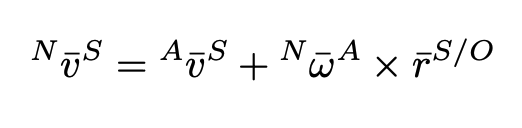

S is not moving when observed from A and O is fixed in A so:

In [9]:
(r_O_P + r_P_S).dt(A) # this will equal 0, becuase of above mentioned conditions.

0

In [10]:
# second term
A.ang_vel_in(N)

α̇ n_z

In [11]:
me.cross(A.ang_vel_in(N), r_O_P + r_P_S)

-d⋅α̇ a_y

In [13]:
# giving N_v_S
N_v_S = (r_O_P + r_P_S).dt(A) + me.cross(A.ang_vel_in(N), r_O_P + r_P_S)
N_v_S

-d⋅α̇ a_y

In [15]:
# Similar, for point Q where P is fixed in B
(r_P_S + r_S_Q).dt(B)


0

In [16]:
me.cross(B.ang_vel_in(N), r_P_S + r_S_Q)

           ⎛     l⎞                ⎛              ⎛     l⎞  ⎞
-d⋅α̇ a_y + ⎜-c - ─⎟⋅sin(β)⋅α̇ b_x + ⎜-w⋅cos(β)⋅α̇ - ⎜-c - ─⎟⋅β̇⎟ b_y + w⋅sin(
           ⎝     2⎠                ⎝              ⎝     2⎠  ⎠


β)⋅α̇ b_z


In [17]:
N_v_Q = (r_P_S + r_S_Q).dt(B) + me.cross(B.ang_vel_in(N), r_P_S + r_S_Q)
N_v_Q

           ⎛     l⎞                ⎛              ⎛     l⎞  ⎞
-d⋅α̇ a_y + ⎜-c - ─⎟⋅sin(β)⋅α̇ b_x + ⎜-w⋅cos(β)⋅α̇ - ⎜-c - ─⎟⋅β̇⎟ b_y + w⋅sin(
           ⎝     2⎠                ⎝              ⎝     2⎠  ⎠


β)⋅α̇ b_z


SymPy Mechanics provides the Point object that simplifies working with position vectors.
Start by creating Points and setting relative positions amoing points using set_pos()

In [20]:
O = me.Point('O')
P = me.Point('P')
S = me.Point('S')
Q = me.Point('Q')

P.set_pos(O, h*N.z)
S.set_pos(P, -d*A.x)
Q.set_pos(S, -w*B.x - (c + l/2)*B.z)

In [25]:
# once relative positions among points are established you can request the position vector between any pair of points
# that are connected by the set_pos() statements, for example r_Q_O is:
Q.pos_from(O)

         ⎛     l⎞
-w b_x + ⎜-c - ─⎟ b_z + -d a_x + h n_z
         ⎝     2⎠

In [26]:
O.set_vel(N,0)

SymPy Mechanics has no way of knowing whether the sculpture is fixed on the road or floating around with some
constant speed. All the relative velocities of the various points would not be changed in those two scenarios. Hence,
at least the speed of one point must be specified.

In [28]:
Q.vel(N)
# this gives the same result as the manually calculated above.

⎛     l⎞                ⎛              ⎛     l⎞  ⎞
⎜-c - ─⎟⋅sin(β)⋅α̇ b_x + ⎜-w⋅cos(β)⋅α̇ - ⎜-c - ─⎟⋅β̇⎟ b_y + w⋅sin(β)⋅α̇ b_z +
⎝     2⎠                ⎝              ⎝     2⎠  ⎠


-d⋅α̇ a_y
